In [2]:
import sys
from pathlib import Path

# Add repo root to Python path
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [3]:
import pandas as pd
from src.data import load_raw_csv
from src.prep import prepare_complaints_df, stratified_cap_per_class, time_split

TEXT_COL = "narrative"
LABEL_COL = "Product"
DATE_COL  = "Date received"

# Load + basic clean
df = load_raw_csv("../data/raw")
df = prepare_complaints_df(df, text_col=TEXT_COL, label_col=LABEL_COL, date_col=DATE_COL, min_chars=20)

# Same label selection as Day 14
top_n = 10
top_labels = df[LABEL_COL].value_counts().head(top_n).index
df = df[df[LABEL_COL].isin(top_labels)].copy()

# Same cap as Day 14
CAP_PER_CLASS = 10000
SEED = 42
df_small = stratified_cap_per_class(df, label_col=LABEL_COL, cap_per_class=CAP_PER_CLASS, random_state=SEED)

# Same time split
train, test = time_split(df_small, date_col=DATE_COL, train_frac=0.8)
X_train, y_train = train["text_clean"], train[LABEL_COL]
X_test,  y_test  = test["text_clean"],  test[LABEL_COL]

print("Train/Test:", len(train), len(test))
print("Labels:", y_train.nunique())

Train/Test: 80000 20000
Labels: 10


C:\Users\praty\OneDrive\Documents\GitHub\Consumer-Complaints-LLM-Analysis\src\prep.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), cap_per_class), random_state=random_state))


In [6]:
import numpy as np
from sentence_transformers import SentenceTransformer

model_name = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)

# Encode in batches; normalize_embeddings=True gives cosine-ready vectors
X_train_emb = embedder.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
).astype("float32")

X_test_emb = embedder.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
).astype("float32")

print("Embeddings shapes:", X_train_emb.shape, X_test_emb.shape)

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Embeddings shapes: (80000, 384) (20000, 384)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Logistic Regression on embeddings
emb_lr = LogisticRegression(
    max_iter=3000,
    n_jobs=-1,
    class_weight="balanced"
)

emb_lr.fit(X_train_emb, y_train)
pred_emb = emb_lr.predict(X_test_emb)

macro_emb = f1_score(y_test, pred_emb, average="macro")
weighted_emb = f1_score(y_test, pred_emb, average="weighted")

print("Embeddings + LogReg Macro F1:", macro_emb)
print("Embeddings + LogReg Weighted F1:", weighted_emb)
print(classification_report(y_test, pred_emb))

c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Embeddings + LogReg Macro F1: 0.5700561645896586
Embeddings + LogReg Weighted F1: 0.6827417361500213
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.67      0.72      0.69      1659
                                                                 Credit card       0.85      0.41      0.55      4513
                                                 Credit card or prepaid card       0.00      0.00      0.00         0
                         Credit reporting or other personal consumer reports       0.87      0.62      0.72      7800
Credit reporting, credit repair services, or other personal consumer reports       0.00      0.00      0.00         0
                                                             Debt collection       0.54      0.49      0.51      1396
                          Money transfer, virtual currency, or money ser

c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

C:\Users\praty\AppData\Local\Temp\ipykernel_29644\231584008.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


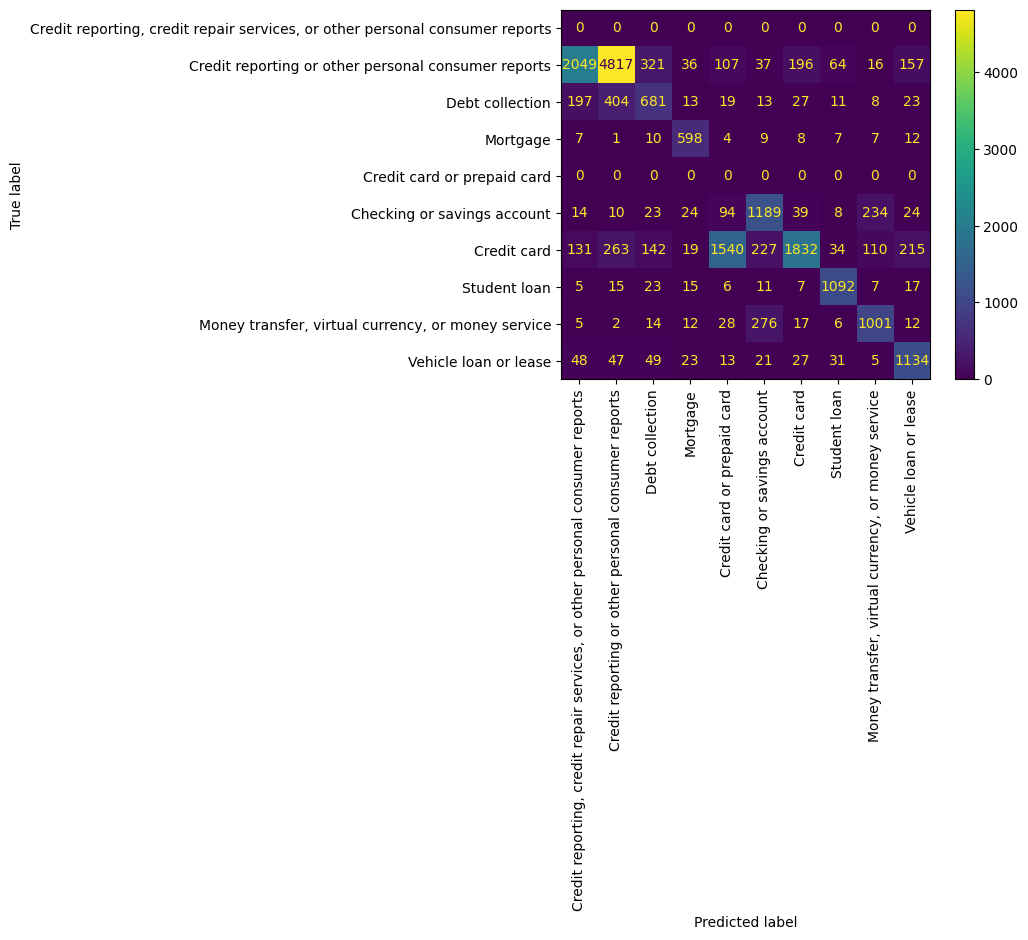

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix for embeddings + LogReg
labels = list(top_labels)

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_emb,
    labels=labels,
    xticks_rotation=90
)
plt.tight_layout()
plt.show()


In [9]:
from pathlib import Path

# Compare with baseline results
baseline_path = Path("../reports/baseline_metrics.csv")
if not baseline_path.exists():
    raise FileNotFoundError("Missing ../reports/baseline_metrics.csv. Run Day 14 notebook first.")

baseline = pd.read_csv(baseline_path)

emb_row = pd.DataFrame([{
    "model": f"Embeddings({model_name}) + LogReg",
    "macro_f1": macro_emb,
    "weighted_f1": weighted_emb,
    "top_n_products": top_n,
    "cap_per_class": CAP_PER_CLASS,
    "vectorizer": "Sentence embeddings (normalized)",
    "split": "time split 80/20"
}])

comparison = pd.concat([baseline, emb_row], ignore_index=True)
comparison = comparison.sort_values("macro_f1", ascending=False)

comparison

,model,macro_f1,weighted_f1,top_n_products,cap_per_class,vectorizer,split
1,Embeddings(all-MiniLM-L6-v2) + LogReg,0.570056,0.682742,10,10000,Sentence embeddings (normalized),time split 80/20
0,TF-IDF + SGD(log_loss),0.461719,0.316900,10,10000,"TF-IDF (1-2 grams, max_features=60000, min_df=10)",time split 80/20


In [10]:
# Save comparison
Path("../reports").mkdir(exist_ok=True)
comparison.to_csv("../reports/day15_model_comparison.csv", index=False)
print("Saved to ../reports/day15_model_comparison.csv")

Saved to ../reports/day15_model_comparison.csv


In [ ]:
import numpy as np

# Nearest neighbors search in test set
test_texts = X_test.tolist()
test_labels = y_test.reset_index(drop=True)
test_embs = X_test_emb  # already normalized float32

def most_similar(query: str, k: int = 5):
    q_emb = embedder.encode([query], normalize_embeddings=True).astype("float32")
    sims = (test_embs @ q_emb.T).ravel()  # cosine similarity since vectors are normalized
    top_idx = np.argsort(-sims)[:k]
    return [(float(sims[i]), test_texts[i], test_labels.iloc[i]) for i in top_idx]

query = "credit card charged twice and the bank is not reversing the transaction"
hits = most_similar(query, k=5)

# Display results
for score, text, label in hits:
    print("\nSCORE:", round(score, 3), "| TRUE PRODUCT:", label)
    print(text[:350], "...")


SCORE: 0.641 | TRUE PRODUCT: Credit card
i made a payment to my credit card i selected an account that i do not use realizing my mistake i called to attempt to cancel i spoke to someone named xxxx chase said that they could not cancel and additionally that they will attempt the payment twice this has now caused me two 32 00 fees in my checking account ...

SCORE: 0.615 | TRUE PRODUCT: Credit card
my credit card was charged xxxx duplicate charge by xxxx xxxx hotel xx xx xxxx xxxx and xx xx xxxx xxxx i only stayed on xx xx xxxx i first called on xxxx after the hotel did nothing to help i have been calling citibank every other week and they have not resolved my issue i want the xxxx refunded to me citibank keeps telling me to wait ...

SCORE: 0.612 | TRUE PRODUCT: Credit card
my credit card was charged for a service i did not receive the credit card company refunded the money to my card and later went a did a credit reversal after i had already expressed that fraud on my card i spoke wit

In [12]:
# Weighted voting from nearest neighbors
def top_k_products_from_neighbors(query: str, k_neighbors: int = 30, top_k_products: int = 3):
    q_emb = embedder.encode([query], normalize_embeddings=True).astype("float32")
    sims = (test_embs @ q_emb.T).ravel()
    idx = np.argsort(-sims)[:k_neighbors]
    # vote by label weighted by similarity
    votes = {}
    for i in idx:
        lab = test_labels.iloc[i]
        votes[lab] = votes.get(lab, 0.0) + float(sims[i])
    ranked = sorted(votes.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k_products]

top_k_products_from_neighbors("mortgage company applied my payment incorrectly and reported delinquency")


[('Mortgage', 14.25131243467331),
 ('Credit reporting or other personal consumer reports', 1.8866588473320007),
 ('Vehicle loan or lease', 1.2994645833969116)]